In [1]:
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

Downloading bucket files: 52931410 / 52931410 complete

Downloading bytes: 52931410 / 52931410 complete

In [2]:
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
analysis_run = ds.pipeline.open(label="docs_default")
graph = analysis_run["connectivity_map"]
all_features = analysis_run["feature_universe"]
ds

annotations = ds.cells.fetch("clusters", key="I")
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
if not source.any() or not sink.any():
    raise ValueError("Source and sink annotations must both be present")
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = -1.0 / source.sum()
source_sink_vector[sink] = 1.0 / sink.sum()
pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
pd.Series({"source cells": int(source.sum()), "sink cells": int(sink.sum())})

source cells     916
sink cells      1142
dtype: int64

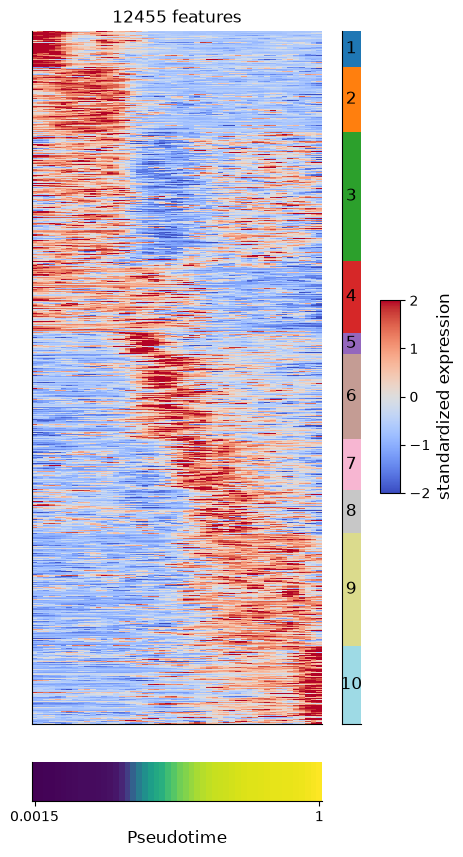

In [3]:
modules_ref = ds.run_pseudotime_aggregation(pseudotime_ref, features=all_features)
ds.plots.pseudotime_heatmap(aggregation=modules_ref)

In [4]:
modules = ds.load_pseudotime_aggregation(modules_ref)
module_genes = pd.DataFrame({
    "gene": modules.feature_names,
    "module": modules.feature_clusters,
})
module_genes.groupby("module").size().rename("genes")

module
1      649
2     1162
3     2324
4     1289
5      392
6     1518
7      921
8      772
9     2022
10    1406
Name: genes, dtype: int64

In [5]:
module_id = module_genes["module"].min()
module_genes.loc[module_genes["module"] == module_id, "gene"].head(20)

17              Mcm3
26             Prim2
52              Uxs1
65            Stk17b
93             Bard1
133              Ncl
139            Hjurp
152             Pask
156            Dtymk
183           Zranb3
184             Mcm6
214    2310009B15Rik
230             Dhx9
231              Npl
257             Fmo4
258             Fmo1
274             Nuf2
280           Nos1ap
319              Lbr
336            Cenpf
Name: gene, dtype: str